In [1]:
import os
from dotenv import load_dotenv
from jupyter_server.auth import login

load_dotenv()

import numpy as np
from openai import OpenAI

FEATHERLESS_API_KEY = os.getenv("FEATHERLESS_API_TOKEN")
FEATHERLESS_MODEL = os.getenv("FEATHERLESS_MODEL")
OPENAI_API_KEY = os.getenv("OPENAI_API_TOKEN")


client = OpenAI(
    api_key=FEATHERLESS_API_KEY,
    base_url="https://api.featherless.ai/v1",
)

def generate(prompt: str, system: str = "You are a helpful assistant.", **kwargs) -> str:
    response = client.chat.completions.create(
        model=FEATHERLESS_MODEL,
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": prompt},
        ],
        **kwargs,
    )
    return response.choices[0].message.content


In [2]:
system_prompt = """You are a creative fiction writer. Write vivid, engaging prose with strong sensory detail."""

user_prompt = """Write a short opening paragraph for a story about a lighthouse keeper who discovers a mysterious object washed ashore during a storm."""

response = generate(
    prompt=user_prompt,
    system=system_prompt,
    max_tokens=300,
    temperature=0.9,
)

print(f"Model: {FEATHERLESS_MODEL}")
print(f"Response length: {len(response)} characters\n")
print("--- Generated Text ---")
print(response)


Model: NousResearch/Hermes-4-14B
Response length: 857 characters

--- Generated Text ---
The relentless fury of the storm threw itself against the treacherous cliffs, a torrent of rain and wind that lashed the rugged shore like a vengeful sea. Inside the dimly lit lighthouse, keeper Alistair Millington huddled over the crackling fire, his gloved hands busying themselves with the meticulous task of tending to the beacon's lamps. Despite the clattering of the gale against the windows and the constant howl of the wind, Alistair's mind wandered to the tales of strange things that washed ashore on nights like these. Old sea legends spoken of ghostly ships and restless spirits, but as he peered out through the grimy panes of glass, a nightmarish vision held his gaze captive. In the midst of the churning waves, a dark, enigmatic form had surmounted the crest of a towering wave, only to be momentarily cast out of sight by the surging abyss.


In [3]:
import json
config = json.load(open("vector_space_config.json"))
for k,v in config.items():
    print(k, ": ", v)

n_dim :  78
n_steps :  10
negative_polarity :  True
hamiltonian_function :  none
basis_set :  cartesian
step_aliases :  ['Present', 'Challenge', 'Conscious Goal', 'Root Cause/Foundation', 'Recent Past', 'Near Future', 'Your Attitude', 'External Influences', 'Hopes and Fears', 'Outcome']
aliases :  ['Ace of Cups', 'Ace of Pentacles', 'Ace of Swords', 'Ace of Wands', 'Death', 'Eight of Cups', 'Eight of Pentacles', 'Eight of Swords', 'Eight of Wands', 'Five of Cups', 'Five of Pentacles', 'Five of Swords', 'Five of Wands', 'Four of Cups', 'Four of Pentacles', 'Four of Swords', 'Four of Wands', 'Judgement', 'Justice', 'King of Cups', 'King of Pentacles', 'King of Swords', 'King of Wands', 'Knight of Cups', 'Knight of Pentacles', 'Knight of Swords', 'Knight of Wands', 'Nine of Cups', 'Nine of Pentacles', 'Nine of Swords', 'Nine of Wands', 'Page of Cups', 'Page of Pentacles', 'Page of Swords', 'Page of Wands', 'Queen of Cups', 'Queen of Pentacles', 'Queen of Swords', 'Queen of Wands', 'Seven 

In [4]:
from itertools import product, combinations

def setup_states_steps(config):
    dims = config.get('aliases', [str(i) for i in range(config['n_dim'])])
    values = ['', ' reversed'] if config.get('negative_polarity', False) else ['']
    n_steps = config['n_steps']
    step_aliases = config.get('step_aliases',[str(i) for i in range(n_steps)])
    #steps = config.get('step_aliases', [str(i) for i in range(config['n_steps'])])
    possible_states = [i[0]+i[1] for i in list(product(dims, values))]
    return possible_states, step_aliases

def setup_all_possibilities(config):
    dims = config.get('aliases', [str(i) for i in range(config['n_dim'])])
    values = ['', ' reversed'] if config.get('negative_polarity', False) else ['']
    n_steps = config['n_steps']
    step_aliases = {i: config.get('step_aliases',str(i)) for i in range(n_steps)}
    #steps = config.get('step_aliases', [str(i) for i in range(config['n_steps'])])
    possible_states = [i[0]+i[1] for i in list(product(dims, values))]
    print(len(possible_states))
    combos = combinations(possible_states, n_steps)
    return combos, step_aliases

possible_states, step_aliases = setup_states_steps(config)
print(f"Possible states: {possible_states}")
print(f"Step aliases: {step_aliases}")


Possible states: ['Ace of Cups', 'Ace of Cups reversed', 'Ace of Pentacles', 'Ace of Pentacles reversed', 'Ace of Swords', 'Ace of Swords reversed', 'Ace of Wands', 'Ace of Wands reversed', 'Death', 'Death reversed', 'Eight of Cups', 'Eight of Cups reversed', 'Eight of Pentacles', 'Eight of Pentacles reversed', 'Eight of Swords', 'Eight of Swords reversed', 'Eight of Wands', 'Eight of Wands reversed', 'Five of Cups', 'Five of Cups reversed', 'Five of Pentacles', 'Five of Pentacles reversed', 'Five of Swords', 'Five of Swords reversed', 'Five of Wands', 'Five of Wands reversed', 'Four of Cups', 'Four of Cups reversed', 'Four of Pentacles', 'Four of Pentacles reversed', 'Four of Swords', 'Four of Swords reversed', 'Four of Wands', 'Four of Wands reversed', 'Judgement', 'Judgement reversed', 'Justice', 'Justice reversed', 'King of Cups', 'King of Cups reversed', 'King of Pentacles', 'King of Pentacles reversed', 'King of Swords', 'King of Swords reversed', 'King of Wands', 'King of Wands 

In [9]:
from coordinate_systems.state_instantiation import Instantiation

TEST_STATE_STEP_DICT = {'Outcome':'Death'}
instant = Instantiation(possible_states, step_aliases, state_step_dict=TEST_STATE_STEP_DICT)
print(instant.instant)



{'Outcome': 'Death', 'Present': 'The Tower', 'Challenge': 'The Magician', 'Conscious Goal': 'The High Priestess', 'Root Cause/Foundation': 'Queen of Wands reversed', 'Recent Past': 'The Lovers reversed', 'Near Future': 'Ten of Cups reversed', 'Your Attitude': 'The World', 'External Influences': 'Ace of Wands', 'Hopes and Fears': 'The Devil'}


In [10]:
from pathlib import Path

def generate_samples(n, possible_states, step_aliases, state_step_dict=None, write_to_file=None,
                     samples_in_memory=False):
    """
    Generate n random Celtic Cross readings.

    Args:
        n:               number of samples
        possible_states: list of state strings (e.g. all card + polarity combos)
        step_aliases:    list of position name strings
        state_step_dict: optional {step: state} dict to pin certain positions
        write_to_file:   optional filename stem; writes JSONL to coordinate_systems/<name>.jsonl

    Returns:
        list of instant dicts [{step_alias: state, ...}, ...]
    """
    samples = []
    writer = None

    if not samples_in_memory and write_to_file is None:
        print("Samples in memory wasn't requested and no file to write specified... I don't know what to do!")
        return

    if write_to_file is not None:
        out_dir = Path("coordinate_systems")
        out_dir.mkdir(exist_ok=True)
        writer = open(out_dir / f"{write_to_file}.jsonl", "w", encoding="utf-8")

    try:
        for _ in range(n):
            instant = Instantiation(possible_states, step_aliases, state_step_dict).instant
            samples.append(instant)
            if writer is not None:
                writer.write(json.dumps(instant) + "\n")
    finally:
        if writer is not None:
            writer.close()

    return samples


In [11]:
def celtic_cross_prompt(instant: dict) -> str:
    return f"""You're a tarot reader. Can you read my Celtic cross tarot? Give an overview of the reading after, any thoughts you have. I'll draw the cards:

Present: {instant['Present']}
Challenge: {instant['Challenge']}
Conscious Goal: {instant['Conscious Goal']}
Root Cause/Foundation: {instant['Root Cause/Foundation']}
Recent Past: {instant['Recent Past']}
Near Future: {instant['Near Future']}
Your Attitude: {instant['Your Attitude']}
External Influences: {instant['External Influences']}
Hopes and Fears: {instant['Hopes and Fears']}
Outcome: {instant['Outcome']}"""


In [14]:
instant = Instantiation(possible_states, step_aliases).instant
prompt = celtic_cross_prompt(instant)
reading = generate(prompt, max_tokens=10000)
print(reading)


Present!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [13]:
print(instant)

{'Present': 'The Wheel of Fortune', 'Challenge': 'Five of Swords reversed', 'Conscious Goal': 'Judgement', 'Root Cause/Foundation': 'King of Wands reversed', 'Recent Past': 'The Devil', 'Near Future': 'Justice reversed', 'Your Attitude': 'The Lovers', 'External Influences': 'Nine of Pentacles', 'Hopes and Fears': 'Two of Swords reversed', 'Outcome': 'The Fool reversed'}


In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict

def generate_sample(i):
    instant = Instantiation(possible_states, step_aliases).instant
    prompt = celtic_cross_prompt(instant)
    reading = generate(prompt, max_tokens=6400)
    return i, instant, prompt, reading

n_samples = 10
samples = defaultdict(dict)

with ThreadPoolExecutor(max_workers=2) as executor:
    futures = {executor.submit(generate_sample, i): i for i in range(n_samples)}
    for future in as_completed(futures):
        i, instant, prompt, reading = future.result()
        print(i)
        samples[i]['instant'] = instant
        samples[i]['prompt'] = prompt
        samples[i]['reading'] = reading
        print(f"Completed {len(samples)}/{n_samples}")


In [11]:
len(samples)

10

In [12]:
samples[1]

{'instant': {'Present': 'Six of Pentacles',
  'Challenge': 'The World reversed',
  'Conscious Goal': 'Queen of Wands',
  'Root Cause/Foundation': 'Queen of Swords reversed',
  'Recent Past': 'Nine of Pentacles reversed',
  'Near Future': 'King of Cups reversed',
  'Your Attitude': 'King of Cups',
  'External Influences': 'Two of Cups reversed',
  'Hopes and Fears': 'The High Priestess',
  'Outcome': 'The Magician reversed'},
 'prompt': "You're a tarot reader. Can you read my Celtic cross tarot? Give an overview of the reading after, any thoughts you have. I'll draw the cards:\n\nPresent: Six of Pentacles\nChallenge: The World reversed\nConscious Goal: Queen of Wands\nRoot Cause/Foundation: Queen of Swords reversed\nRecent Past: Nine of Pentacles reversed\nNear Future: King of Cups reversed\nYour Attitude: King of Cups\nExternal Influences: Two of Cups reversed\nHopes and Fears: The High Priestess\nOutcome: The Magician reversed",
 'reading': "Here's an overview of your Celtic cross tar

In [13]:
import re

EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL")
EMBEDDING_MODEL = EMBEDDING_MODEL or "Qwen/Qwen3-Embedding-8B"

def split_into_chunks(text: str) -> list[str]:
    chunks = re.split(r'(?<=[.!?])\s+|\n+', text)
    return [c.strip() for c in chunks if c.strip()]

def embed(text: str) -> list[float]:
    response = client.embeddings.create(
        model=EMBEDDING_MODEL,
        input=text,
    )
    return response.data[0].embedding

def embed_samples(samples: dict, max_workers=2) -> dict:
    def embed_one(i):
        chunks = split_into_chunks(samples[i]['reading'])
        embeddings = [embed(chunk) for chunk in chunks]
        return i, chunks, embeddings

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(embed_one, i): i for i in samples}
        for future in as_completed(futures):
            i, chunks, embeddings = future.result()
            samples[i]['chunks'] = chunks
            samples[i]['embeddings'] = embeddings
            print(f"Embedded {sum('embeddings' in v for v in samples.values())}/{len(samples)}")

    return samples



In [22]:
samples = embed_samples(samples)

Embedded 1/10
Embedded 2/10
Embedded 3/10
Embedded 4/10
Embedded 5/10
Embedded 6/10
Embedded 7/10
Embedded 8/10
Embedded 9/10
Embedded 10/10


In [23]:
np.linalg.norm(np.array(samples[0]['embeddings']),axis=1)

array([1.00000005, 1.00000001, 0.99999997, 0.99999998, 1.        ,
       1.00000002, 1.00000005, 0.99999999, 1.00000003, 1.00000002,
       1.00000007, 0.99999994, 0.99999999, 1.00000009, 1.00000001,
       1.00000003, 0.99999998, 0.99999999, 1.        , 1.00000003,
       1.        , 1.        , 1.00000003, 1.00000006, 0.99999998,
       1.00000001, 1.00000006, 0.99999993, 1.00000001, 1.00000004,
       0.99999999, 0.99999995, 1.00000002, 0.99999996, 0.99999999])

In [9]:
from dynamicalembeddings.dynamicalembedding import DynamicalEmbedding
from text_tokenizers.whitespace import WhitespaceTokenizer

In [17]:
entity_check = generate("Create an exhaustive list of entities from the following text... just return a each entity in double quotations, separated by a comma. Here's the text: "+samples[0]['reading'], max_tokens=4800)

In [19]:
entity_check

'"Two of Cups reversed", "Seven of Cups reversed", "Eight of Wands reversed", "The World", "Three of Pentacles", "The Magician", "Three of Pentacles", "Page of Cups reversed", "Seven of Wands reversed", "The Hanged Man", "Celtic Cross spread"'

In [8]:
from collections import defaultdict
d = DynamicalEmbedding(samples[0]['reading'])
d.process_text(tokenizer=WhitespaceTokenizer())
print(d.outputs['tokens'])

NameError: name 'DynamicalEmbedding' is not defined

In [20]:
pl_check = generate("Create an exhaustive list of predicate logic statements from the following text.  "+samples[0]['reading'], max_tokens=4800)
print(pl_check)

1. Present: Two of Cups reversed (¬EmotionalConnection ∧ ¬BalancedRelationships)
2. Challenge: Seven of Cups reversed (¬DecisionMaking ∧ ¬OverwhelmedByChoices)
3. Conscious Goal: Eight of Wands reversed (¬Frustration ∧ ¬BlockedEfforts)
4. Root Cause/Foundation: The World (Completion ∧ Fulfillment ∧ Success ∧ SolidFoundation ∧ PotentialForGrowth)
5. Recent Past: Three of Pentacles (WorkingOnProject ∧ Collaboration ∧ WellReceivedEfforts ∧ Progress)
6. Near Future: The Magician (Power ∧ Resources ∧ ManifestDesires ∧ TakeControl ∧ CreatePositiveChange)
7. Your Attitude: Three of Pentacles (ConfidenceInAbilities ∧ StrongTeamwork ∧ StrongCollaboration)
8. External Influences: Page of Cups reversed (¬MixedMessages ∧ ¬EmotionalTurmoil)
9. Hopes and Fears: Seven of Wands reversed (¬UncertaintyAboutFuture ∧ ¬StrugglingToDefendPosition)
10. Outcome: The Hanged Man (StepBack ∧ ReassessSituation ∧ Patience ∧ TrustInProcess ∧ ThingsWorkOut)

11. (¬EmotionalConnection ∧ ¬BalancedRelationships) → Chal

In [21]:
ner_coref_prompt = """
You are an information extraction system. Given the text below, identify all entity mentions and group them into coreference clusters.

Instructions:
1. Find every mention that refers to a real-world entity — this includes proper nouns (e.g., "John Smith"), definite noun phrases (e.g., "the patient", "the company"), and pronouns (e.g., "he", "it", "they").
2. Assign each mention a character start/end offset within the text.
3. Group mentions that refer to the same real-world entity into a single cluster.
4. For each cluster, assign an entity type from this list: PERSON, ORGANIZATION, LOCATION, ROLE, DATE, OTHER.
5. Within each cluster, pick the most specific/informative mention as the "canonical_name".
6. Return ONLY valid JSON, no preamble, no markdown code fences, matching this schema:

{{
  "clusters": [
    {{
      "cluster_id": 0,
      "entity_type": "PERSON",
      "canonical_name": "John Smith",
      "mentions": [
        {{"text": "John Smith", "start": 0, "end": 10}}
      ]
    }}
  ]
}}

Text:
<<<START_TEXT>>>
{text}
<<<END_TEXT>>>
"""

prompt = ner_coref_prompt.format(text=samples[0]['reading'])



In [27]:
ner_coref_check = generate(prompt, max_tokens=4800)

In [24]:
print(ner_coref_check)

{
  "clusters": [
    {
      "cluster_id": 0,
      "entity_type": "OTHER",
      "canonical_name": "Celtic Cross spread",
      "mentions": [
        {"text": "Celtic Cross spread", "start": 36, "end": 51}
      ]
    },
    {
      "cluster_id": 1,
      "entity_type": "OTHER",
      "canonical_name": "Two of Cups reversed",
      "mentions": [
        {"text": "Two of Cups reversed", "start": 71, "end": 87}
      ]
    },
    {
      "cluster_id": 2,
      "entity_type": "OTHER",
      "canonical_name": "Seven of Cups reversed",
      "mentions": [
        {"text": "Seven of Cups reversed", "start": 131, "end": 149}
      ]
    },
    {
      "cluster_id": 3,
      "entity_type": "OTHER",
      "canonical_name": "Eight of Wands reversed",
      "mentions": [
        {"text": "Eight of Wands reversed", "start": 183, "end": 200}
      ]
    },
    {
      "cluster_id": 4,
      "entity_type": "OTHER",
      "canonical_name": "The World",
      "mentions": [
        {"text": "The Worl

In [26]:
prompt = ner_coref_prompt.format(text="Patient came in with a massive headache and conjuctivitis. He said he had been out drinking all night")
ner_coref_check = generate(prompt, max_tokens=4800)
print(ner_coref_check)

{
  "clusters": [
    {
      "cluster_id": 0,
      "entity_type": "PERSON",
      "canonical_name": "Patient",
      "mentions": [
        {"text": "Patient", "start": 0, "end": 7}
      ]
    },
    {
      "cluster_id": 1,
      "entity_type": "PERSON",
      "canonical_name": "He",
      "mentions": [
        {"text": "He", "start": 32, "end": 34}
      ]
    }
  ]
}


In [28]:
text = "Patient came in with a massive headache and conjuctivitis. He said he had been out drinking all night"

# single tok_len
de = DynamicalEmbedding(text, spacing=10)
# → outputs['subtexts'] = {"tok_len_10": [...]}

# multiple tok_lens (shorthand list)
de = DynamicalEmbedding(text, spacing=[5, 10, 20])
# → outputs['subtexts'] = {"tok_len_5": [...], "tok_len_10": [...], "tok_len_20": [...]}

# mixed tok_len and char_len via dict
de = DynamicalEmbedding(text, spacing={"tok_len": [5, 10], "char_len": [100, 300]})
print(de.outputs)
# → outputs['subtexts'] = {"tok_len_5": [...], "tok_len_10": [...], "char_len_100": [...], "char_len_300": [...]}

# no subtexts
de = DynamicalEmbedding(text)
# → outputs has no 'subtexts' key

defaultdict(<class 'dict'>, {'tokens': [Token(text='Patient', start=0, end=7, id=None, label=None), Token(text='came', start=8, end=12, id=None, label=None), Token(text='in', start=13, end=15, id=None, label=None), Token(text='with', start=16, end=20, id=None, label=None), Token(text='a', start=21, end=22, id=None, label=None), Token(text='massive', start=23, end=30, id=None, label=None), Token(text='headache', start=31, end=39, id=None, label=None), Token(text='and', start=40, end=43, id=None, label=None), Token(text='conjuctivitis.', start=44, end=58, id=None, label=None), Token(text='He', start=59, end=61, id=None, label=None), Token(text='said', start=62, end=66, id=None, label=None), Token(text='he', start=67, end=69, id=None, label=None), Token(text='had', start=70, end=73, id=None, label=None), Token(text='been', start=74, end=78, id=None, label=None), Token(text='out', start=79, end=82, id=None, label=None), Token(text='drinking', start=83, end=91, id=None, label=None), Token(t

In [23]:
from text_tokenizers import SpacyTokenizer
import spacy
nlp = spacy.load("en_core_web_sm")
check = nlp("Hi is this working? I'm on an American Airlines flight")

In [32]:
check.doc

Hi is this working? I'm on an American Airlines flight

In [15]:
from nnsight import CONFIG
from IPython.display import clear_output

CONFIG.API.APIKEY = os.getenv("NDIF_API_TOKEN")
clear_output()

from nnsight.modeling.language import LanguageModel


#model = LanguageModel("EleutherAI/gpt-j-6b")
#model = LanguageModel("google/gemma-2-9b-it")
model = LanguageModel("meta-llama/Llama-3.1-70B-Instruct", device_map="auto")

print(model)
print(model.model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 8192)
    (layers): ModuleList(
      (0-79): 80 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=8192, out_features=8192, bias=False)
          (k_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (v_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (o_proj): Linear(in_features=8192, out_features=8192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (up_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (down_proj): Linear(in_features=28672, out_features=8192, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((8192,), eps=1e-05)
  

In [ ]:
import torch

#with model.trace(prompt, remote=True):  # flip to True for NDIF
#    # Save every transformer layer's output in one pass
#    all_hidden_states = [
#        layer.output[0].save() for layer in model.model.layers
#    ]

#    # Stack into shape [num_layers, batch, seq_len, hidden_dim]
#    hidden_states_tensor = torch.stack([h for h in all_hidden_states])
#    print(hidden_states_tensor.shape)

instant = Instantiation(possible_states, step_aliases).instant
prompt = celtic_cross_prompt(instant)

with model.generate(prompt, max_new_tokens=50, remote=True) as tracer:
    # advance to the final step without capturing the intermediate ones
    #for _ in range(49):
    #    tracer.next()
    hidden_states = list().save()
    tokens = list().save()

    with tracer.all():
        step_hidden_states = torch.stack(
            [layer.output[0].cpu() for layer in model.model.layers]
        )
        #step_hidden_states = torch.stack([layer.output[0] for layer in model.model.layers])
        hidden_states.append(step_hidden_states)
        token = model.lm_head.output[0, -1].argmax(dim=-1)
        tokens.append(token)

    #final_hidden = model.model.layers[-1].output[0].save()
    #output = model.generator.output.save()



In [16]:
import torch
def collect_hidden_states(text, model):
    with model.trace(text, remote=True) as tracer:
        # advance to the final step without capturing the intermediate ones
        #for _ in range(49):
        #    tracer.next()

        step_hidden_states = torch.stack(
                [layer.output[0].cpu() for layer in model.model.layers]
            )
        step_hidden_states = torch.squeeze(step_hidden_states).save()
        token = model.lm_head.output[0, -1].argmax(dim=-1).save()
    return step_hidden_states, token

#hidden_states, token = collect_hidden_states("A magnifying glass can be used to see an insect without making it appear bigger.",model)

In [17]:
premises = {1: "An insect usually has a small size.", 2: "A magnifying glass is used to see small things by making objects appear bigger."}
conclusion = "Therefore, a magnifying glass can be used to see an insect by making it appear bigger."

not_entailed = [
    "A magnifying glass can be used to see an insect without making it appear bigger.",
    "A magnifying glass cannot be used to see an insect by making it appear bigger.",
    "A magnifying glass can be used to see an insect by making it appear smaller.",
    "A magnifying glass can be used to see an insect before making it appear bigger.",
    "A magnifying glass can be used to see an insect after making it appear bigger.",
    "A magnifying glass can be used to see an insect instead of making it appear bigger.",
    "A magnifying glass cannot be used to see an insect by making it appear smaller.",
    "A magnifying glass may be used to see an insect without making the insect appear bigger.",
    "A magnifying glass can be used to see an insect, but it cannot make the insect appear bigger.",
    "A magnifying glass can be used to see an insect only when it does not make it appear bigger."
]

statements = {**{'premise_'+str(k):v for k,v in premises.items()},
              **{'conclusion_1': conclusion},
              **{"not_entailed_"+str(not_entailed.index(s)+1):s for s in not_entailed}
              }

embeds = {}
for k,v in statements.items():
    embeds[k], token = collect_hidden_states(v, model)


⬇ Downloading:   0%|          | 0.00/9.22M [00:00<?]

⬇ Downloading:   0%|          | 0.00/17.4M [00:00<?]

⬇ Downloading:   0%|          | 0.00/20.4M [00:00<?]

⬇ Downloading:   0%|          | 0.00/18.4M [00:00<?]

⬇ Downloading:   0%|          | 0.00/18.4M [00:00<?]

...

⬇ Downloading:   0%|          | 0.00/19.4M [00:00<?]

⬇ Downloading:   0%|          | 0.00/18.4M [00:00<?]

⬇ Downloading:   0%|          | 0.00/19.4M [00:00<?]

⬇ Downloading:   0%|          | 0.00/22.5M [00:00<?]

⬇ Downloading:   0%|          | 0.00/22.5M [00:00<?]

In [11]:
import pandas as pd
import seaborn as sns

torch.Size([9, 8192])


<Axes: >

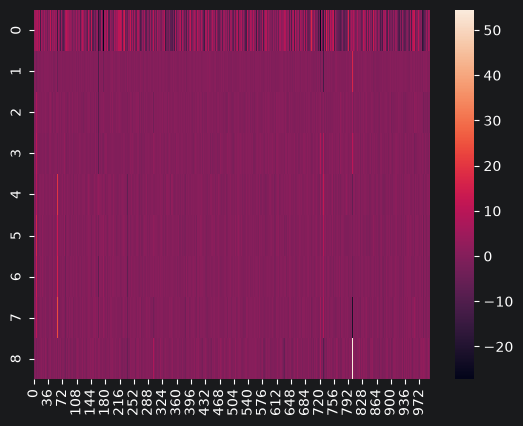

In [48]:
test = embeds['premise_1']
diff = test[-1] - test[0]
print(diff.shape)
#import seaborn as sns
sns.heatmap(diff.detach().float().numpy()[:,-3000:-2000])

#var, mean = torch.var_mean(test, dim=1)
#pd.Series(var.mean(-1).detach().float().numpy()).plot()
#pd.Series(mean.mean(-1).detach().float().numpy()).plot()

In [36]:
model.tokenizer.decode(tokens)
hidden_states

[tensor([[[ 9.1171e-04,  5.0049e-03, -1.7700e-03,  ...,  2.8381e-03,
            9.0332e-03,  7.0496e-03],
          [ 3.2654e-03, -6.8359e-03, -3.1433e-03,  ...,  1.1292e-02,
           -1.1230e-02, -3.3264e-03],
          [ 6.9580e-03, -2.9907e-03, -8.7280e-03,  ...,  1.0376e-02,
           -4.8523e-03,  1.9836e-03],
          ...,
          [ 7.6294e-06, -3.5706e-03,  2.9755e-03,  ...,  4.3335e-03,
            5.7373e-03, -5.3711e-03],
          [ 6.6223e-03, -2.8992e-04, -7.3242e-03,  ..., -6.6528e-03,
            9.2773e-03,  9.5825e-03],
          [-8.9722e-03,  2.7924e-03, -6.4087e-03,  ..., -5.6152e-03,
           -8.5449e-03,  1.6113e-02]],
 
         [[ 9.4604e-04,  4.6387e-03, -3.7384e-03,  ...,  1.3733e-03,
            9.3384e-03,  7.2021e-03],
          [ 5.9814e-03, -7.2021e-03, -2.3804e-03,  ...,  9.0332e-03,
           -1.7456e-02, -5.3101e-03],
          [ 3.2196e-03,  4.6997e-03, -7.4158e-03,  ...,  1.3855e-02,
           -6.5308e-03,  2.9755e-03],
          ...,
    

In [42]:
print(len(hidden_states))
(hidden_states[34].size())

50


torch.Size([80, 1, 8192])

In [40]:
len(model.tokenizer(prompt)['input_ids'])

118

In [43]:
for h in hidden_states:
    size_mb = h.numel() * h.element_size() / (1024 ** 2)
    print(size_mb)

147.5
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25
1.25


In [45]:
hidden_states[23].shape

torch.Size([80, 1, 8192])

In [46]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 8192)
    (layers): ModuleList(
      (0-79): 80 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=8192, out_features=8192, bias=False)
          (k_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (v_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (o_proj): Linear(in_features=8192, out_features=8192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (up_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (down_proj): Linear(in_features=28672, out_features=8192, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((8192,), eps=1e-05)
  

In [12]:
# is there a way to run this

#def format_add_id(text, equ_id=None):
#    if equ_id is None:
#        equ_id = 's1'

equ = ["Magnifying glasses help you see insects better.", "A magnifying glass can be used to see an insect more clearly.", "A magnifying glass can be used to see an insect more clearly, since it makes the insect's small size appear larger and easier to observe.", "A magnifying glass can be used to see an insect more clearly, since it makes the insect appear larger than its actual small size.", "A magnifying glass can be used to view an insect, making it appear larger and easier to see its small details.", "A magnifying glass can be used to see an insect more clearly, since it makes the small insect appear larger and easier to observe in detail.", "Using a magnifying glass to look at an insect will make the insect appear larger, making it easier to see its small details clearly.", "The insect appears bigger when viewed through the magnifying glass.", "A magnifying glass can be used to make an insect appear bigger, so its small details are easier to see."]

embeds = {}
for i, s in enumerate(equ):
    embeds[i], token = collect_hidden_states(s, model)

⬇ Downloading:   0%|          | 0.00/10.2M [00:00<?]

⬇ Downloading:   0%|          | 0.00/15.3M [00:00<?]

⬇ Downloading:   0%|          | 0.00/30.6M [00:00<?]

⬇ Downloading:   0%|          | 0.00/28.6M [00:00<?]

⬇ Downloading:   0%|          | 0.00/25.6M [00:00<?]

⬇ Downloading:   0%|          | 0.00/30.7M [00:00<?]

⬇ Downloading:   0%|          | 0.00/28.6M [00:00<?]

⬇ Downloading:   0%|          | 0.00/13.3M [00:00<?]

⬇ Downloading:   0%|          | 0.00/24.5M [00:00<?]

In [14]:
embeds[0].shape

torch.Size([80, 10, 8192])

In [42]:
t = torch.stack([e.mean(dim=1) for e in embeds.values()])
subtract = t[:,1:,:] - t[:,:-1,:]
print(subtract.shape)

torch.Size([9, 79, 8192])


In [43]:
var, mean = torch.var_mean(t,dim=0)
var_sub, mean_sub = torch.var_mean(subtract,dim=0)

<Axes: >

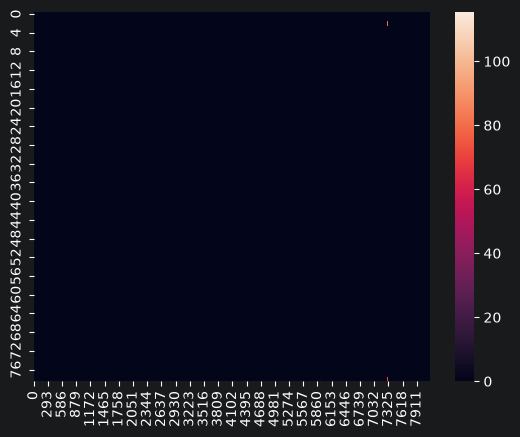

In [45]:
import seaborn as sns
#sns.heatmap(mean.detach().float().numpy())
sns.heatmap(var_sub.detach().float().numpy())

<Axes: >

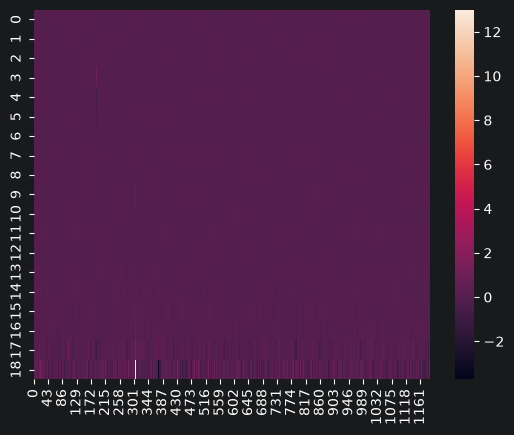

In [57]:
sns.heatmap(subtract[3,60:,7000:].detach().float().numpy())

In [30]:
# variance.shape == (80, 8192)

flat_indices = torch.argsort(var.flatten(), descending=True)

layer_indices = flat_indices // var.shape[1]
hidden_indices = flat_indices % var.shape[1]

indices = torch.stack([layer_indices, hidden_indices], dim=1)

print(indices.shape)
# torch.Size([655360, 2])

torch.Size([655360, 2])


In [32]:
indices[:10]

tensor([[  49, 1532],
        [  51, 1532],
        [  47, 1532],
        [  45, 1532],
        [  48, 1532],
        [  77, 1532],
        [  61, 1532],
        [  37, 1532],
        [  41, 1532],
        [  35, 1532]])

<Axes: >

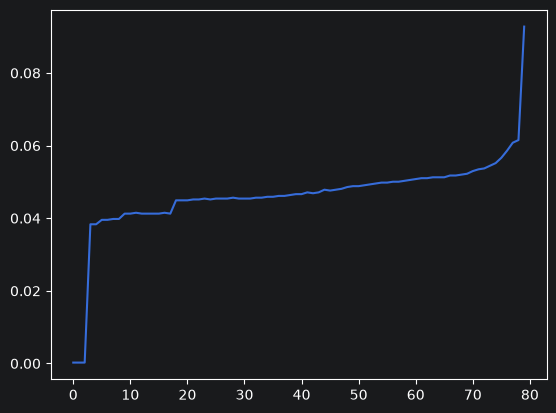

In [38]:
import pandas as pd
pd.Series(var.mean(-1).float().detach().numpy()).plot()

<Axes: >

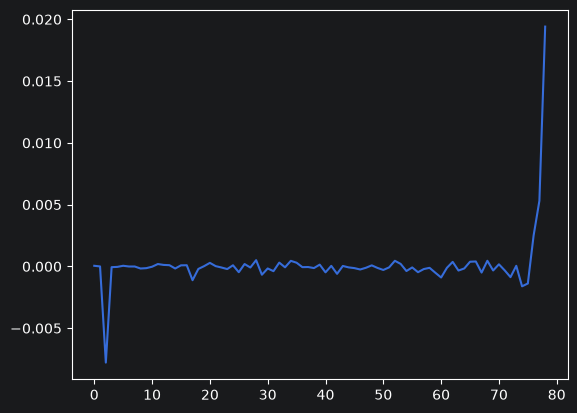

In [58]:
pd.Series(mean_sub.mean(-1).float().detach().numpy()).plot()

On mean of tokens per layer per embedding space:
1) mean of variance per layer per hidden dim
    - Trial: almost no variance in first few layers, sudden spike around layer 4, then leveling off and steady rise, then sudden spike towards the end

On subtraction of tokens per layer per embedding space:
1)


Could redo heatmaps so they exclude dimensions/layers that don't change

In [66]:
print(embeds[0].shape)
layer_norms = torch.linalg.vector_norm(embeds[0], ord=2, dim=-1)

print(layer_norms.mean())
# torch.Size([80])

torch.Size([80, 10, 8192])
tensor(98., dtype=torch.bfloat16)


In [21]:
model.model.layers[1].input_layernorm

LlamaRMSNorm((8192,), eps=1e-05)

Structure of code:
1) Models
    a) LanguageModel (White Box)
    b) EmbeddingModel (Sentence Embeddings)
    c) TextGenerator (Black Box)
2) DynamicalEmbedding
3) Prompts
4) IdeaBank
    a) Outputs to : Prompts. Entities?
    b) Should there be an idea agent?
    c) Basic components should be entities (not necessarily proper ones). Entity graph?
    d) Could tie into predicate logic statements. The generated sentences must fit specific placements in the predicate logic

What measurements?
1) Points
    a) could be derived from different paths
        i) Means
            1. 

